In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 


## step1 :loading the dataset(kaggle,google dataset, visual data, openml)


In [2]:
df=pd.read_excel("C:\\Dataset\\ml_project_dataset.xlsx")

In [3]:
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True


In [4]:
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_preg       768 non-null    int64  
 1   glucose_conc   768 non-null    int64  
 2   diastolic_bp   768 non-null    int64  
 3   thickness      768 non-null    int64  
 4   insulin        768 non-null    int64  
 5   bmi            768 non-null    float64
 6   diab_pred      768 non-null    float64
 7   age            768 non-null    int64  
 8   diabetes_orig  768 non-null    int64  
 9   skin           768 non-null    float64
 10  has_diabetes   768 non-null    bool   
 11  diabetes       768 non-null    bool   
dtypes: bool(2), float64(3), int64(7)
memory usage: 61.6 KB


In [6]:
df.shape

(768, 12)

In [7]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

## step2 :cleaning the dataset
## a. check the null values is present in dataset or not

In [8]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

## checking the corelation between two columns

In [9]:
def check_corr(size):
    corr=df.corr()
    fig,ax=plt.subplots(figsize=(size,size))
    ax.matshow(corr,cmap='rainbow')
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.show()

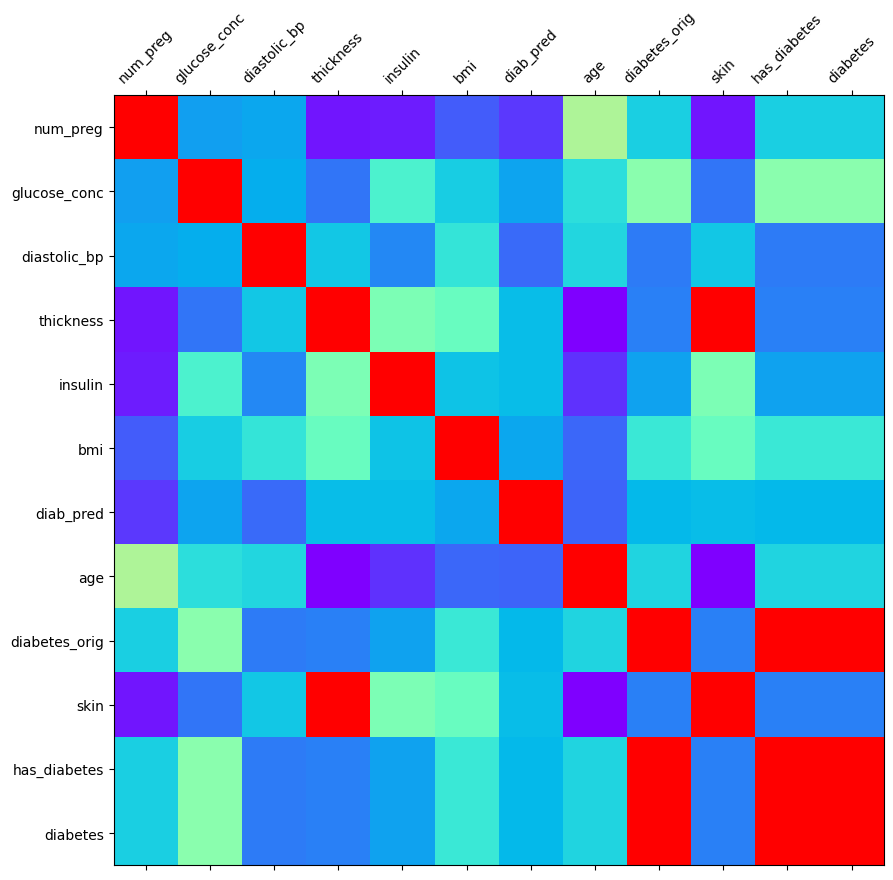

In [10]:
check_corr(10)

In [11]:
# 1. thickness and skill are corelated to each other
# 2. diabetes_orig and has_diabetes are corelated to each other
# 3. diabetes_orig and diabetes are corelated to each other
# 4. has_diabetes and diabetes are corelated to each other

## c.drop the corelated columns 

In [12]:
df.drop('thickness',axis=1,inplace=True)
df.drop('diabetes_orig',axis=1,inplace=True)
df.drop('has_diabetes',axis=1,inplace=True)

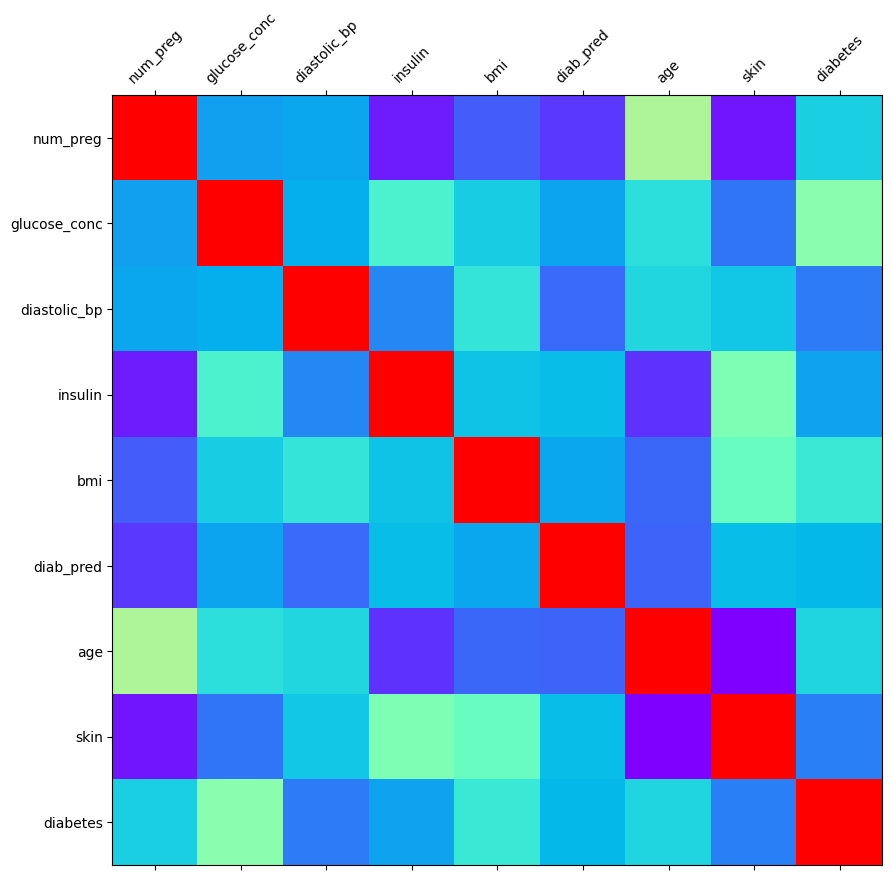

In [13]:
check_corr(10)

## 4. convert string data to integer type

In [14]:
df['diabetes'].unique()

array([ True, False])

In [15]:
df['diabetes']=df['diabetes'].map({True:1,False:0})
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


## 5.check the propertion of data

In [16]:
num_true=len(df.loc[df['diabetes']==1])
num_false=len(df.loc[df['diabetes']==0])
print(f"num of true data is {num_true}")
print(f"num of false data is {num_false}")

num of true data is 268
num of false data is 500


In [17]:
true_per=(num_true/(num_true+num_false))*100
false_per=(num_false/(num_true+num_false))*100
print(f"true value percentage is {true_per}")
print(f"false value percentage is {false_per}")

true value percentage is 34.89583333333333
false value percentage is 65.10416666666666


## step3: Train test split

In [18]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [19]:
input_columns=['num_preg','glucose_conc','diastolic_bp','insulin','bmi','diab_pred','age','skin']
output_columns=['diabetes']

In [20]:
x=df[input_columns].values
y=df[output_columns].values

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [23]:
def m1(x,y):
    return x+y,x-y
sum1,sub1=m1(10,20)
print(sum1)
print(sub1)

30
-10


In [24]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


## check the tarining and testing percentage after train test split

In [25]:
print('{0:0.2f} % in train set'.format((len(x_train)/len(df.index))*100))
print('{0:0.2f} % in train set'.format((len(x_test)/len(df.index))*100))

69.92 % in train set
30.08 % in train set


In [26]:
print('training true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),
                                            (len(y_train[y_train[:]==1])/len(y_train)*100)))
print('training false:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),
                                            (len(y_train[y_train[:]==0])/len(y_train)*100)))

training true:188 (35.01%)
training false:349 (64.99%)


In [27]:
print('testing true:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==1]),
                                            (len(y_test[y_test[:]==1])/len(y_train)*100)))
print('testing false:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==0]),
                                            (len(y_test[y_test[:]==0])/len(y_train)*100)))

testing true:80 (14.90%)
testing false:151 (28.12%)


## setp5: post split preparation

In [28]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [29]:
total_num_preg=len(df.loc[df['num_preg']==0])
print(f"total num of rows missing in num_preg column is {total_num_preg}")

total_glucose_conc=len(df.loc[df['glucose_conc']==0])
print(f"total num of rows missing in glucose_conc column is {total_glucose_conc}")

total_diastolic_bp=len(df.loc[df['diastolic_bp']==0])
print(f"total num of rows missing in diastolic_bp column is {total_diastolic_bp}")


total_insulin=len(df.loc[df['insulin']==0])
print(f"total num of rows missing in insulin column is {total_insulin}")

total_bmi=len(df.loc[df['bmi']==0])
print(f"total num of rows missing in bmi column is {total_bmi}")

total_diab_pred=len(df.loc[df['diab_pred']==0])
print(f"total num of rows missing in diab_pred column is {total_diab_pred}")

total_age=len(df.loc[df['age']==0])
print(f"total num of rows missing in age column is {total_age}")

total_skin=len(df.loc[df['skin']==0])
print(f"total num of rows missing in skin column is {total_skin}")

total_diabetes=len(df.loc[df['diabetes']==0])
print(f"total num of rows missing in diabetes column is {total_diabetes}")

total num of rows missing in num_preg column is 111
total num of rows missing in glucose_conc column is 5
total num of rows missing in diastolic_bp column is 35
total num of rows missing in insulin column is 374
total num of rows missing in bmi column is 11
total num of rows missing in diab_pred column is 0
total num of rows missing in age column is 0
total num of rows missing in skin column is 227
total num of rows missing in diabetes column is 500


In [30]:
from sklearn.impute import SimpleImputer

In [31]:
x_train[:5]

array([[1.0000e+00, 9.5000e+01, 6.0000e+01, 5.8000e+01, 2.3900e+01,
        2.6000e-01, 2.2000e+01, 7.0920e-01],
       [5.0000e+00, 1.0500e+02, 7.2000e+01, 3.2500e+02, 3.6900e+01,
        1.5900e-01, 2.8000e+01, 1.1426e+00],
       [0.0000e+00, 1.3500e+02, 6.8000e+01, 2.5000e+02, 4.2300e+01,
        3.6500e-01, 2.4000e+01, 1.6548e+00],
       [4.0000e+00, 1.3100e+02, 6.8000e+01, 1.6600e+02, 3.3100e+01,
        1.6000e-01, 2.8000e+01, 8.2740e-01],
       [1.0000e+00, 1.0300e+02, 3.0000e+01, 8.3000e+01, 4.3300e+01,
        1.8300e-01, 3.3000e+01, 1.4972e+00]])

In [32]:
fill_zeros=SimpleImputer(missing_values=0,strategy='mean')
x_train=fill_zeros.fit_transform(x_train)
x_test=fill_zeros.fit_transform(x_test)

In [33]:
x_train[:5]

array([[1.00000000e+00, 9.50000000e+01, 6.00000000e+01, 5.80000000e+01,
        2.39000000e+01, 2.60000000e-01, 2.20000000e+01, 7.09200000e-01],
       [5.00000000e+00, 1.05000000e+02, 7.20000000e+01, 3.25000000e+02,
        3.69000000e+01, 1.59000000e-01, 2.80000000e+01, 1.14260000e+00],
       [4.34056399e+00, 1.35000000e+02, 6.80000000e+01, 2.50000000e+02,
        4.23000000e+01, 3.65000000e-01, 2.40000000e+01, 1.65480000e+00],
       [4.00000000e+00, 1.31000000e+02, 6.80000000e+01, 1.66000000e+02,
        3.31000000e+01, 1.60000000e-01, 2.80000000e+01, 8.27400000e-01],
       [1.00000000e+00, 1.03000000e+02, 3.00000000e+01, 8.30000000e+01,
        4.33000000e+01, 1.83000000e-01, 3.30000000e+01, 1.49720000e+00]])

## step6: training the model    16/4/2026

## standardize the data

In [34]:
# from sklearn.preprocessing import StandardScaler
# scalar=StandardScaler()
# x_train=scalar.fit_transform(x_train)
# x_test=scalar.fit_transform(x_test)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [35]:
# x_train[:5]

y_train=y_train.astype(int).ravel()
y_test=y_test.astype(int).ravel()
print(y_train.shape)
print(y_test.shape)

(537,)
(231,)


## train the model using navie bayees

In [36]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train)

GaussianNB()

In [37]:
from sklearn import metrics
nb_predict_model=nb_model.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,nb_predict_model)}")

predicted accuracy for training data 0.7541899441340782


In [38]:
nb_predict_test=nb_model.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,nb_predict_test)}")

predicted accuracy for testing data 0.7359307359307359


## step 6  test the accuracy using confusion matrix   17/4/2026

In [39]:
print(f"{metrics.confusion_matrix(y_test,nb_predict_test)}")

# (tn fp,fn,tp) return type of confusion_matrix

[[118  33]
 [ 28  52]]


## step 6 test the accuracy using classification_report

In [40]:
print(f"{metrics.classification_report(y_test,nb_predict_test)}")

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       151
           1       0.61      0.65      0.63        80

    accuracy                           0.74       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.74      0.74       231



## train the model using random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [42]:
from sklearn import metrics
rf_predict_model=rf_model.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,rf_predict_model)}")

predicted accuracy for training data 1.0


In [43]:
rf_predict_test=rf_model.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,rf_predict_test)}")

predicted accuracy for testing data 0.7532467532467533


In [44]:
print(f"{metrics.confusion_matrix(y_test,rf_predict_test)}")

[[120  31]
 [ 26  54]]


In [45]:
print(f"{metrics.classification_report(y_test,rf_predict_test)}")

              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.64      0.68      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



## train the model using knn

In [46]:
from sklearn.neighbors import KNeighborsClassifier
k_neighbour=KNeighborsClassifier()
k_neighbour.fit(x_train,y_train)

KNeighborsClassifier()

In [47]:
from sklearn import metrics
k_predict_model=k_neighbour.predict(x_train)
print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,k_predict_model)}")

predicted accuracy for training data 0.8379888268156425


In [48]:
k_predict_test=k_neighbour.predict(x_test)
print(f"predicted accuracy for testing data {metrics.accuracy_score(y_test,k_predict_test)}")

predicted accuracy for testing data 0.7012987012987013


In [49]:
print(f"{metrics.confusion_matrix(y_test,k_predict_test)}")

[[113  38]
 [ 31  49]]


In [50]:
print(f"{metrics.classification_report(y_test,k_predict_test)}")

              precision    recall  f1-score   support

           0       0.78      0.75      0.77       151
           1       0.56      0.61      0.59        80

    accuracy                           0.70       231
   macro avg       0.67      0.68      0.68       231
weighted avg       0.71      0.70      0.70       231



## testing the model  20/4/2026

In [51]:
#input_data=[6,148,72,0,33.6,0.627,50,1.3790]  # diabrtic data 

input_data=[1,85,66,0,26.6,0.351,31,1.142]    # non diabetic

input_array=np.asarray(input_data).reshape(1,-1)
input_array=fill_zeros.transform(input_array)
input_array=scaler.transform(input_array)
print(input_array)
prediction=rf_model.predict(input_array)
print("Prediction:","Diabetic" if prediction[0]==1 else "Not a Diabetic")

[[-1.15687814 -1.22831158 -0.51185924  0.00844534 -0.81575723 -0.34795441
  -0.17769495  0.03984074]]
Prediction: Not a Diabetic


In [52]:
import pickle
# save model
with open('rf_model.pkl','wb') as f:
    pickle.dump(rf_model,f)

# save scaler
with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

# savee imputer
with open('imputer.pkl','wb') as f:
    pickle.dump(fill_zeros,f)

In [53]:
import sklearn
print(sklearn.__version__)

1.5.1
